# Trece huesos, dos positivos: el genoma de la viruela que llegó a América

De trece muestras de hueso del norte de Chile, dos guardaban ADN del virus. Es la primera lectura del genoma de la viruela que entró a América — y el linaje que encontraron está extinto: no aparece en ninguna cepa conocida, ni antigua ni moderna.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** [The genomic identity of early smallpox in South America](https://doi.org/10.1126/science.aee6957) · *Science*, 30 de julio de 2026
**DOI:** [10.1126/science.aee6957](https://doi.org/10.1126/science.aee6957)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-31-viruela-antigua-sudamerica/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/nzvCAJbcli4)

## De qué van estos datos

El sitio se llama Camarones 9 y está en el norte de Chile. Ahí había dos personas enterradas — una mujer de 30 a 35 años, un hombre de 18 a 20 — que murieron en algún momento entre 1492 y 1631. El equipo recuperó ADN de viruela de sus restos, ensambló el genoma y lo comparó con genomas medievales europeos y con las cepas modernas del siglo XX.

Lo que exploramos aquí son las tablas del paper: a qué velocidad acumuló mutaciones el virus en cada tramo de su árbol, y cuántos de sus genes ya estaban rotos cuando llegó a América.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RAMA_CONSTRENIDA = 'mVARV_to_mVARV_P-I+P-II'   # la rama 1594-1794 CE
CLASE_CANONICA   = 'intact_gene'               # genes que aún funcionan
CLASE_CONTROL    = 'inactive_gene (aVARV+CAM9+mVARV)'  # pseudogenes = control neutro
FUENTE = 'Fuente: Romero González et al. (2026), Science | Datos: Tablas S10-S14 del mismo paper'

COLOR_DATOS      = '#2563EB'   # tasas sinónimas / dato principal
COLOR_ALERTA     = '#DC2626'   # la rama constreñida
COLOR_SECUNDARIO = '#059669'   # inventario de genes
COLOR_REFERENCIA = '#D97706'   # ventana de constricción / umbrales
COLOR_ACENTO     = '#7C3AED'   # tasas no sinónimas
COLOR_CONTEXTO   = '#BBBBBB'   # fondo / control

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM: local en el repo, o inyectado en /tmp dentro del contenedor
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)


def fmt_es(x, dec=2):
    # Formato español: miles con punto, decimales con coma (regla 39)
    s = f'{x:,.{dec}f}'
    return s.replace(',', '@').replace('.', ',').replace('@', '.')


# ── Carga de datos ────────────────────────────────────────────────
tasas      = pd.read_csv('datos/substitution_rates.csv')
grupos     = pd.read_csv('datos/gene_status_by_group.csv')
por_genoma = pd.read_csv('datos/gene_status_per_genome.csv')
linajes    = pd.read_csv('datos/inactivation_by_lineage.csv')
mutaciones = pd.read_csv('datos/inactivating_mutations.csv')
cobertura  = pd.read_csv('datos/genome_coverage.csv')

print('Genomas antiguos recuperados')
for _, r in cobertura.iterrows():
    print(f'  {r["sample"]}: cobertura {fmt_es(r.mean_depth_x, 3)}x  |  '
          f'{fmt_es(r.breadth_pct_1x, 2)}% del genoma cubierto  |  '
          f'{fmt_es(r.dedup_mapped_reads, 0)} lecturas')

roto = por_genoma[por_genoma.status_cam9_208.isin(['Absent', 'Inactive', 'Possibly inactive'])]
print(f'\nGenes analizados en CAM9_208: {len(por_genoma)}')
print(f'  rotos (ausentes + inactivos + posiblemente inactivos): {len(roto)} '
      f'({fmt_es(100 * len(roto) / len(por_genoma), 1)}%)')
print(f'  posiblemente intactos: {(por_genoma.status_cam9_208 == "Possibly intact").sum()}')

print('\nRamas del árbol con tasas calculadas (genes intactos)')
print('dS = mutaciones silenciosas | dN = mutaciones que cambian la proteína:')
intactos = tasas[tasas.gene_class == CLASE_CANONICA].sort_values('start_year_ce')
for _, r in intactos.iterrows():
    print(f'  {round(r.start_year_ce)}-{round(r.end_year_ce)} CE  '
          f'dS={fmt_es(r.ds * 1e6, 2):>5} ×10⁻⁶   dN={fmt_es(r.dn * 1e6, 2):>4} ×10⁻⁶   '
          f'dN/dS={fmt_es(r.dn_ds, 3)}')

Genomas antiguos recuperados
  CAM9_208: cobertura 84,851x  |  98,99% del genoma cubierto  |  183.566 lecturas
  CAM9_205: cobertura 3,206x  |  90,57% del genoma cubierto  |  4.805 lecturas

Genes analizados en CAM9_208: 214
  rotos (ausentes + inactivos + posiblemente inactivos): 49 (22,9%)
  posiblemente intactos: 164

Ramas del árbol con tasas calculadas (genes intactos)
dS = mutaciones silenciosas | dN = mutaciones que cambian la proteína:
  1296-1594 CE  dS=22,25 ×10⁻⁶   dN=3,27 ×10⁻⁶   dN/dS=0,147
  1594-1794 CE  dS= 5,87 ×10⁻⁶   dN=1,57 ×10⁻⁶   dN/dS=0,267
  1794-1905 CE  dS=18,55 ×10⁻⁶   dN=3,51 ×10⁻⁶   dN/dS=0,189
  1794-1888 CE  dS=18,14 ×10⁻⁶   dN=2,47 ×10⁻⁶   dN/dS=0,136


## Aquí está.

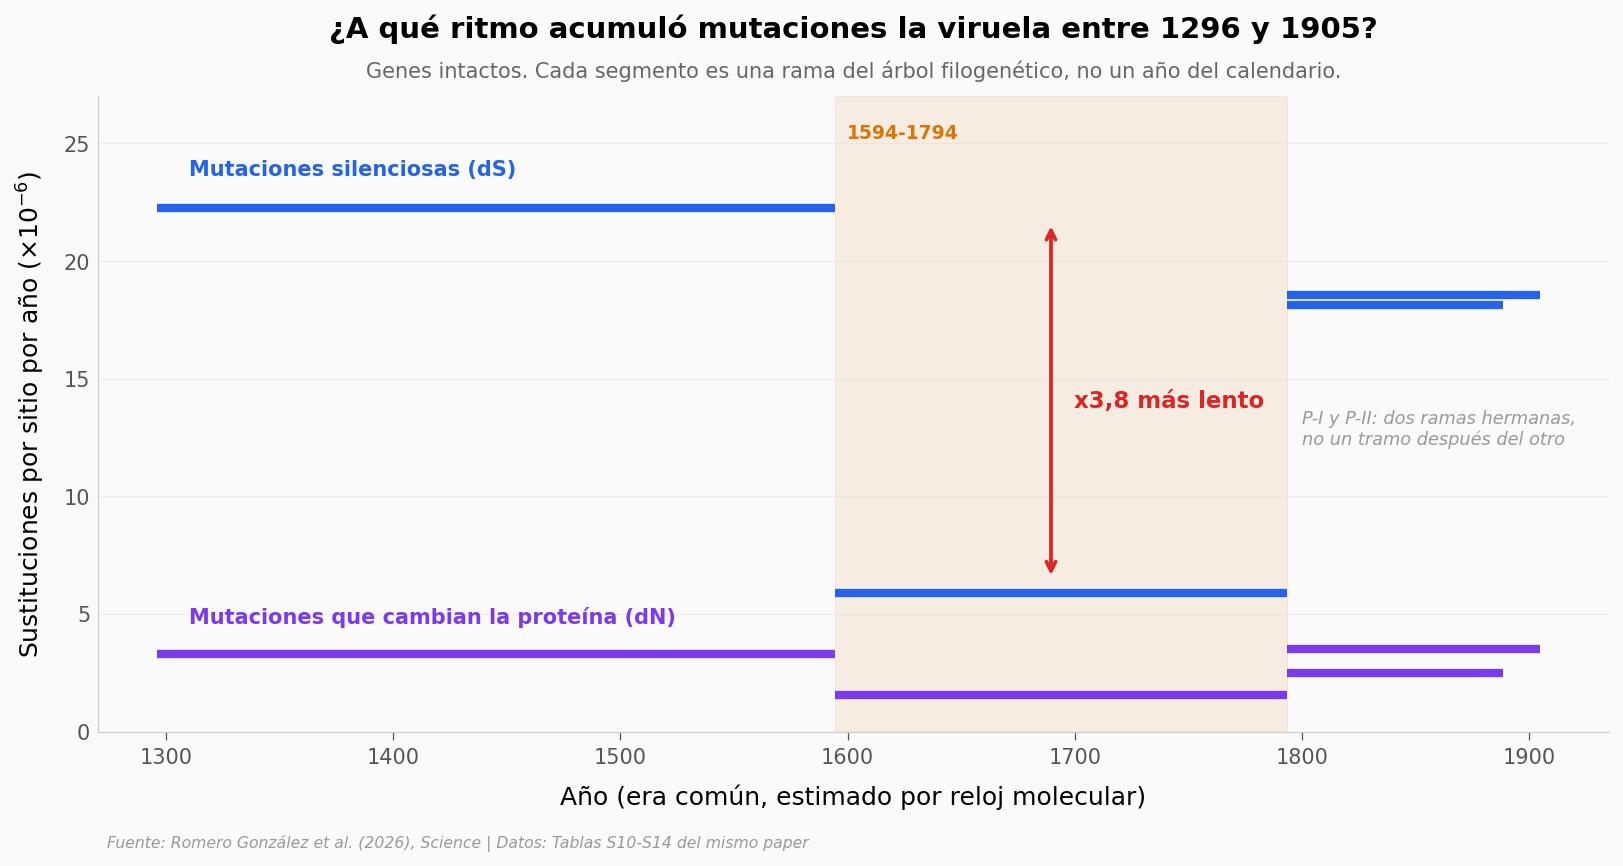

Rama lenta (1594-1794): 34 sustituciones silenciosas / 32 que cambian la proteína
Las otras tres ramas:   303 silenciosas / 164 en proteína
Prueba exacta de Fisher sobre la asimetría: p = 0,041


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

intactos = tasas[tasas.gene_class == CLASE_CANONICA].sort_values('start_year_ce')

# Ventana de constricción (la rama 1594-1794)
banda = intactos[intactos.branch == RAMA_CONSTRENIDA].iloc[0]
ax.axvspan(banda.start_year_ce, banda.end_year_ce,
           color=COLOR_REFERENCIA, alpha=0.10, zorder=0)

for _, r in intactos.iterrows():
    ax.plot([r.start_year_ce, r.end_year_ce], [r.ds * 1e6] * 2,
            color=COLOR_DATOS, lw=4, solid_capstyle='butt', zorder=5)
    ax.plot([r.start_year_ce, r.end_year_ce], [r.dn * 1e6] * 2,
            color=COLOR_ACENTO, lw=4, solid_capstyle='butt', zorder=5)

# Inline labels (reemplazan la caja de leyenda)
primera = intactos.iloc[0]
ax.text(1310, primera.ds * 1e6 + 1.4, 'Mutaciones silenciosas (dS)',
        fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.text(1310, primera.dn * 1e6 + 1.3, 'Mutaciones que cambian la proteína (dN)',
        fontsize=10, color=COLOR_ACENTO, fontweight='bold')

# La caída
caida = primera.ds / banda.ds
ax.annotate('', xy=(banda.start_year_ce + 95, banda.ds * 1e6 + 0.6),
            xytext=(banda.start_year_ce + 95, primera.ds * 1e6 - 0.6),
            arrowprops=dict(arrowstyle='<->', color=COLOR_ALERTA, lw=1.8))
ax.text(banda.start_year_ce + 105, (primera.ds + banda.ds) * 1e6 / 2,
        f'x{fmt_es(caida, 1)} más lento', fontsize=11,
        fontweight='bold', color=COLOR_ALERTA, va='center')

ax.text(banda.start_year_ce + 5, 25.2, '1594-1794', fontsize=9,
        color=COLOR_REFERENCIA, fontweight='bold')
ax.text(1800, 12.2, 'P-I y P-II: dos ramas hermanas,\nno un tramo después del otro',
        fontsize=8.5, color='#999999', style='italic')

ax.set_title('¿A qué ritmo acumuló mutaciones la viruela entre 1296 y 1905?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Genes intactos. Cada segmento es una rama del árbol filogenético, no un año del calendario.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año (era común, estimado por reloj molecular)')
ax.set_ylabel('Sustituciones por sitio por año (×10$^{-6}$)')
ax.set_xlim(1270, 1935)
ax.set_ylim(0, 27)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tasas_por_rama.png', dpi=200, bbox_inches='tight')
plt.show()

# ¿Se frenan igual las silenciosas que las que cambian la proteína?
# Conteos de sustituciones -> prueba exacta de Fisher (no aplica Cohen's d aquí:
# no hay grupos de tratamiento, son conteos con exposición).
from scipy import stats as st

lenta  = intactos[intactos.branch == RAMA_CONSTRENIDA]
otras3 = intactos[intactos.branch != RAMA_CONSTRENIDA]
tabla_2x2 = [[int(lenta.synonymous.sum()),  int(lenta.nonsynonymous.sum())],
             [int(otras3.synonymous.sum()), int(otras3.nonsynonymous.sum())]]
odds, p_asim = st.fisher_exact(tabla_2x2)

print(f'Rama lenta (1594-1794): {tabla_2x2[0][0]} sustituciones silenciosas / '
      f'{tabla_2x2[0][1]} que cambian la proteína')
print(f'Las otras tres ramas:   {tabla_2x2[1][0]} silenciosas / {tabla_2x2[1][1]} en proteína')
print(f'Prueba exacta de Fisher sobre la asimetría: p = {fmt_es(p_asim, 3)}')

## Lo que llama la atención

El tramo que va de 1594 a 1794 es el más lento de los cuatro: en los genes que todavía funcionan, las mutaciones silenciosas caen entre 3,1 y 3,8 veces respecto a las otras ramas. Y después vuelven a subir.

La asimetría es lo interesante. Las mutaciones silenciosas —las que no tocan la proteína— se frenan más que las que sí la cambian, que caen entre 1,6 y 2,2 veces. Con los conteos de la tabla S14 la diferencia entre ambas clases da p = 0,04 en una prueba exacta: apunta en una sola dirección, pero con margen estrecho. Cuando un virus atraviesa menos personas, acumula menos mutaciones de todo tipo; que las silenciosas se frenen más es la firma que el equipo interpreta como un cambio en la presión sobre el virus, no solo menos contagios.

Un detalle de lectura: los dos segmentos finales se solapan en el tiempo porque son ramas hermanas del árbol —dos linajes que corren en paralelo desde 1794— y no dos periodos consecutivos.

## Ahora los genes

Las tasas cuentan la velocidad. La otra mitad de la historia es cuántas piezas del virus ya estaban rotas cuando llegó a Chile — y desde cuándo.

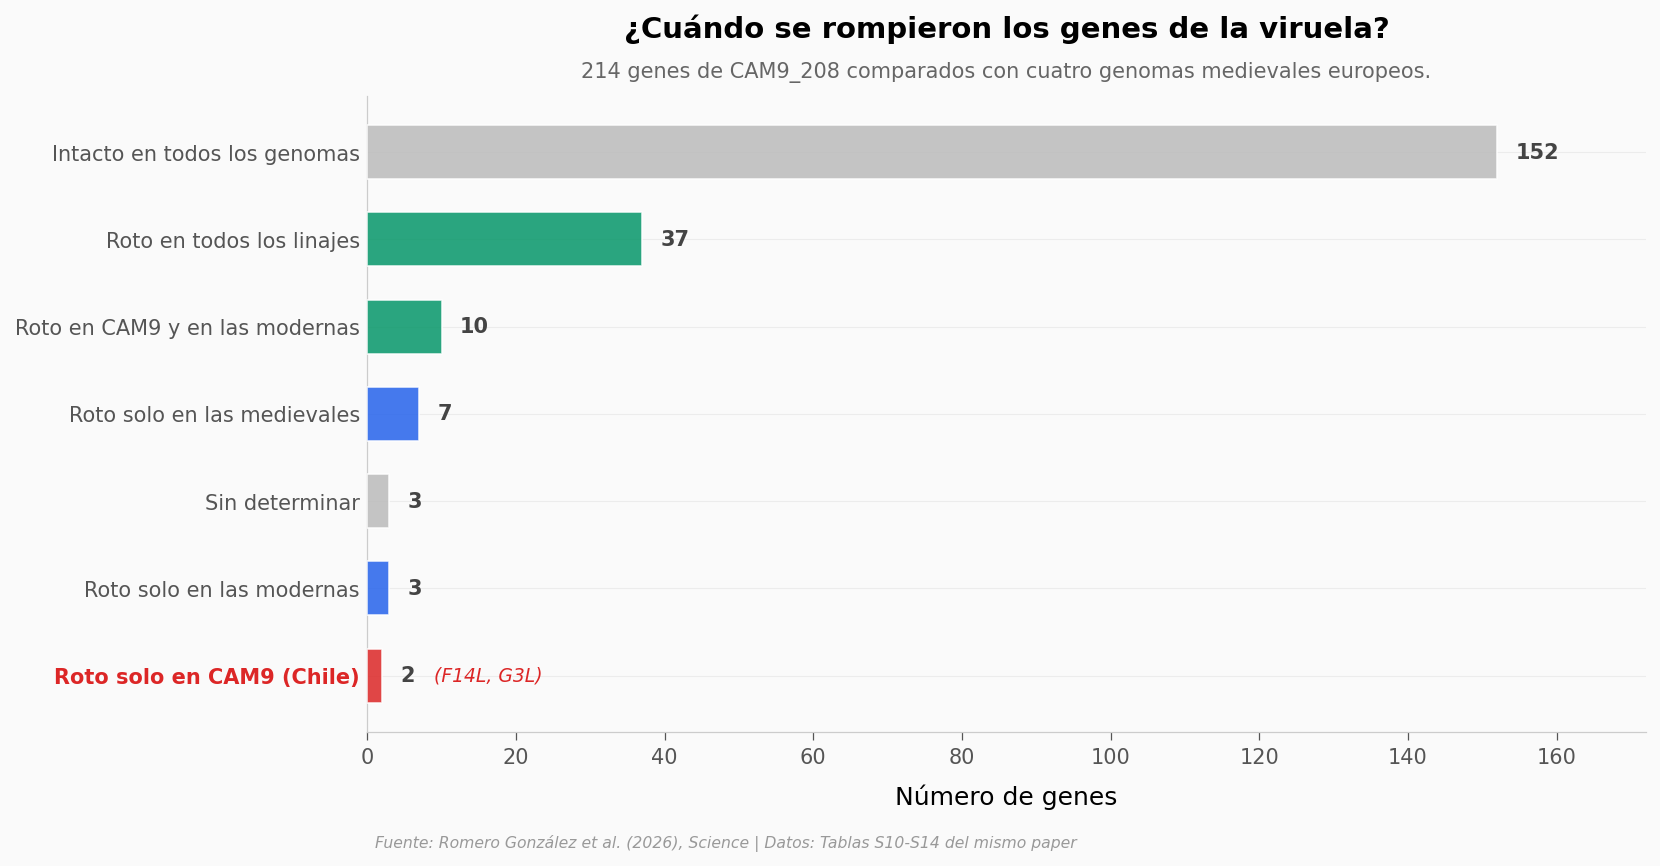

Genes rotos en CAM9_208: 49 de 214
  ya rotos antes de que el linaje se separara: 37
  exclusivos del linaje chileno: 2 (F14L, G3L)


In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

etiquetas = {
    'Intact':           'Intacto en todos los genomas',
    'aVARV+CAM9+mVARV': 'Roto en todos los linajes',
    'CAM9+mVARV':       'Roto en CAM9 y en las modernas',
    'aVARV':            'Roto solo en las medievales',
    'Undetermined':     'Sin determinar',
    'mVARV':            'Roto solo en las modernas',
    'CAM9':             'Roto solo en CAM9 (Chile)',
}
orden = ['Intact', 'aVARV+CAM9+mVARV', 'CAM9+mVARV', 'aVARV', 'Undetermined', 'mVARV', 'CAM9']
lin = linajes.set_index('lineage_group').loc[orden].reset_index()

colores = [COLOR_CONTEXTO, COLOR_SECUNDARIO, COLOR_SECUNDARIO, COLOR_DATOS,
           COLOR_CONTEXTO, COLOR_DATOS, COLOR_ALERTA]
y = np.arange(len(lin))[::-1]
ax.barh(y, lin.n_genes, color=colores, alpha=0.85, height=0.62,
        edgecolor='white', linewidth=0.8, zorder=5)

for yi, n in zip(y, lin.n_genes):
    ax.text(n + 2.5, yi, str(n), va='center', fontsize=10, fontweight='bold',
            color='#444444')

ax.set_yticks(y)
ax.set_yticklabels([etiquetas[g] for g in lin.lineage_group], fontsize=10)
ax.get_yticklabels()[-1].set_color(COLOR_ALERTA)
ax.get_yticklabels()[-1].set_fontweight('bold')

genes_cam9 = ', '.join(por_genoma[por_genoma.lineage_group == 'CAM9'].gene_label)
ax.text(9, 0, f'({genes_cam9})', fontsize=9, color=COLOR_ALERTA,
        style='italic', va='center')

ax.set_title('¿Cuándo se rompieron los genes de la viruela?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '214 genes de CAM9_208 comparados con cuatro genomas medievales europeos.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Número de genes')
ax.set_xlim(0, 172)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/genes_por_linaje.png', dpi=200, bbox_inches='tight')
plt.show()

roto_n = int(lin[lin.lineage_group != 'Intact'].n_genes.sum() - lin[lin.lineage_group.isin(['Undetermined', 'aVARV', 'mVARV'])].n_genes.sum())
print(f'Genes rotos en CAM9_208: {roto_n} de {int(lin.n_genes.sum())}')
print(f'  ya rotos antes de que el linaje se separara: {int(lin[lin.lineage_group == "aVARV+CAM9+mVARV"].n_genes.iloc[0])}')
print(f'  exclusivos del linaje chileno: {int(lin[lin.lineage_group == "CAM9"].n_genes.iloc[0])} ({genes_cam9})')

## ¿Y qué pasó después de Chile?

Entre el linaje chileno y la viruela moderna del siglo XX hay unos 300 años de camino. El paper lista las mutaciones que rompieron genes en cada tramo — y ahí aparece algo que conviene mirar con cuidado.

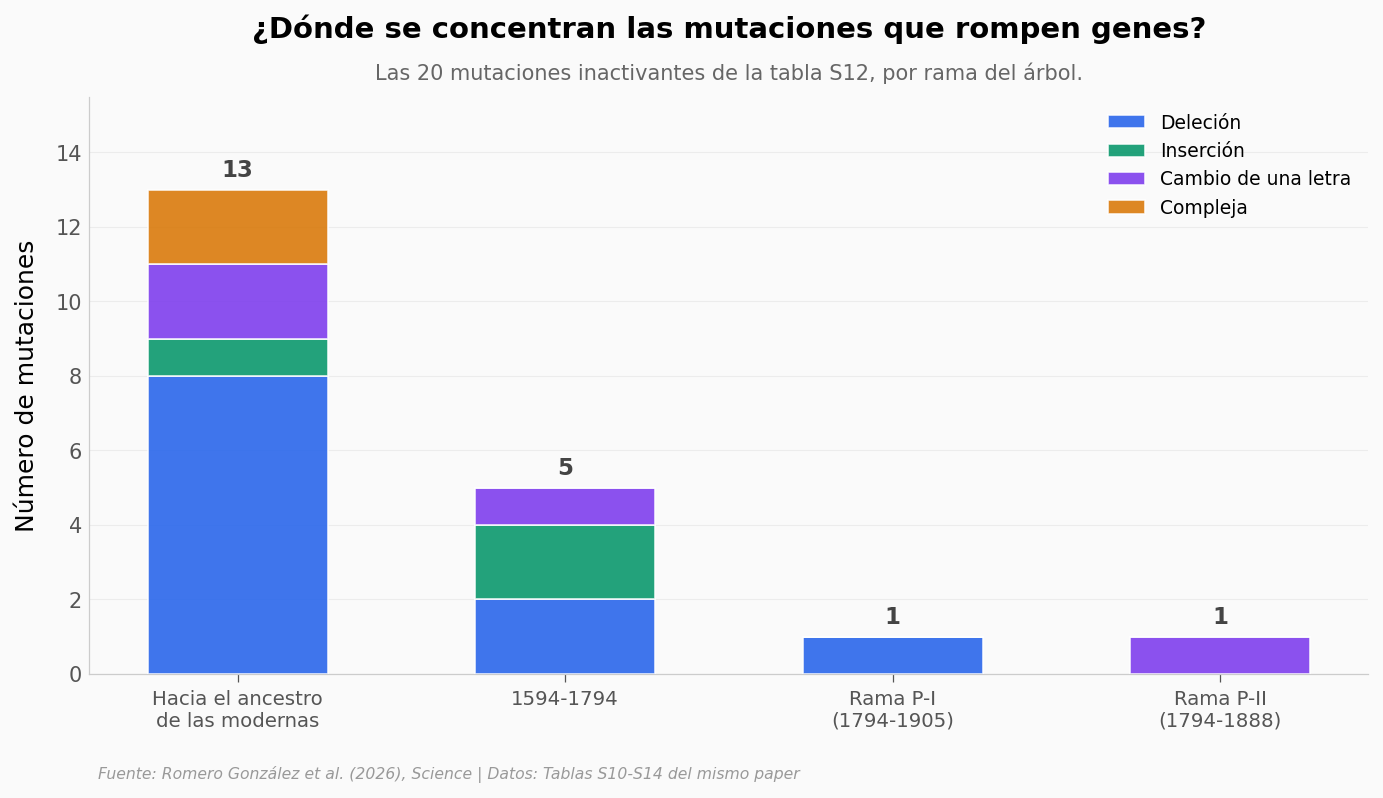

Mutaciones en la rama hacia las modernas: 13
  genes tocados: 7 -> A56R, B15R, B20R, B6R, C5L, E7R, F15L
  genes que quedan clasificados como rotos nuevos: 3 -> B6R, C5L, E7R


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

nombre_rama = {
    'CAM9+mVARV_to_mVARV':          'Hacia el ancestro\nde las modernas',
    'mVARV_to_mVARV_P-I+P-II':      '1594-1794',
    'mVARV_P-I+P-II_to_mVARV_P-I':  'Rama P-I\n(1794-1905)',
    'mVARV_P-I+P-II_to_mVARV_P-II': 'Rama P-II\n(1794-1888)',
}
nombre_tipo = {'del': 'Deleción', 'ins': 'Inserción',
               'snp': 'Cambio de una letra', 'complex': 'Compleja'}
color_tipo = {'del': COLOR_DATOS, 'ins': COLOR_SECUNDARIO,
              'snp': COLOR_ACENTO, 'complex': COLOR_REFERENCIA}

orden_ramas = list(nombre_rama.keys())
tabla = (mutaciones.groupby(['branch', 'mutation_type']).size()
         .unstack(fill_value=0).reindex(orden_ramas, fill_value=0))

x = np.arange(len(orden_ramas))
base = np.zeros(len(orden_ramas))
for tipo in ['del', 'ins', 'snp', 'complex']:
    if tipo not in tabla.columns:
        continue
    vals = tabla[tipo].values
    ax.bar(x, vals, bottom=base, color=color_tipo[tipo], alpha=0.88,
           width=0.55, edgecolor='white', linewidth=0.8,
           label=nombre_tipo[tipo], zorder=5)
    base += vals

for xi, total in zip(x, tabla.sum(axis=1).values):
    ax.text(xi, total + 0.35, str(int(total)), ha='center', fontsize=11,
            fontweight='bold', color='#444444')

ax.set_xticks(x)
ax.set_xticklabels([nombre_rama[b] for b in orden_ramas], fontsize=9.5)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

ax.set_title('¿Dónde se concentran las mutaciones que rompen genes?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las 20 mutaciones inactivantes de la tabla S12, por rama del árbol.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Número de mutaciones')
ax.set_ylim(0, 15.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mutaciones_por_rama.png', dpi=200, bbox_inches='tight')
plt.show()

rama_larga = 'CAM9+mVARV_to_mVARV'
genes_tocados = sorted(mutaciones[mutaciones.branch == rama_larga].gene_label.unique())
nuevos_rotos = sorted(por_genoma[por_genoma.lineage_group == 'mVARV'].gene_label)
print(f'Mutaciones en la rama hacia las modernas: {int(tabla.loc[rama_larga].sum())}')
print(f'  genes tocados: {len(genes_tocados)} -> {", ".join(genes_tocados)}')
print(f'  genes que quedan clasificados como rotos nuevos: {len(nuevos_rotos)} -> {", ".join(nuevos_rotos)}')

## Trece mutaciones, tres genes rotos

Mira los números que quedaron arriba. En la rama que lleva a la viruela moderna hay 13 mutaciones repartidas en 7 genes — pero solo 3 de esos genes (C5L, E7R y B6R) terminan clasificados como rotos nuevos. Una mutación dentro de un gen no lo apaga automáticamente: algunas le quitan un pedazo sin desordenar la forma en que se lee el resto del gen —el marco de lectura— y la proteína sigue saliendo bien.

Esa distinción —mutación observada frente a gen efectivamente inactivado— es la que sostiene el resultado central del paper. Y lleva a la última pregunta: ¿qué tan rara es, de verdad, la rama lenta?

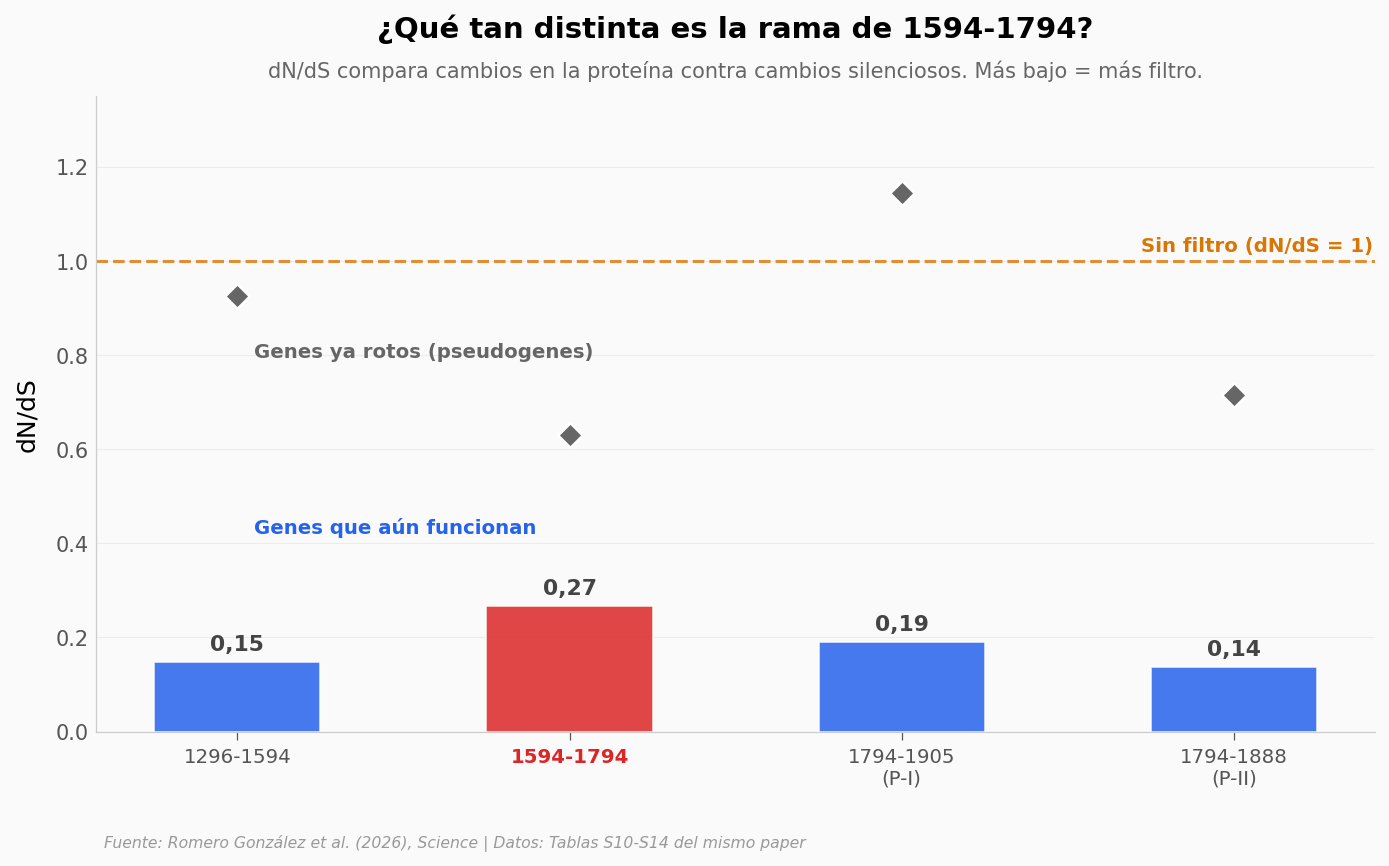

dN/dS de genes intactos en 1594-1794: 0,267
  otras tres ramas: 0,147, 0,189, 0,136
Control neutro (genes ya rotos): media 0,854, rango 0,630-1,145


In [5]:
# Cierre cuantitativo. El paper compara 4 ramas discretas (no una distribución),
# así que el cierre es un comparativo con control neutro en vez de un histograma.
fig, ax = plt.subplots(figsize=(11, 5.5))

etiqueta_rama = {
    'CAM9_to_mVARV':                '1296-1594',
    'mVARV_to_mVARV_P-I+P-II':      '1594-1794',
    'mVARV_P-I+P-II_to_mVARV_P-I':  '1794-1905\n(P-I)',
    'mVARV_P-I+P-II_to_mVARV_P-II': '1794-1888\n(P-II)',
}
orden = list(etiqueta_rama.keys())

int_ = tasas[tasas.gene_class == CLASE_CANONICA].set_index('branch').loc[orden]
ctrl = tasas[tasas.gene_class == CLASE_CONTROL].set_index('branch').loc[orden]

x = np.arange(len(orden))
colores = [COLOR_ALERTA if b == RAMA_CONSTRENIDA else COLOR_DATOS for b in orden]
ax.bar(x, int_.dn_ds.values, color=colores, alpha=0.85, width=0.5,
       edgecolor='white', linewidth=0.8, zorder=5)

for xi, v in zip(x, int_.dn_ds.values):
    ax.text(xi, v + 0.025, fmt_es(v, 2), ha='center', fontsize=10.5,
            fontweight='bold', color='#444444')

ax.scatter(x, ctrl.dn_ds.values, color='#666666', s=70, marker='D',
           edgecolors='white', linewidths=1.2, zorder=6)

ax.axhline(y=1.0, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(3.42, 1.02, 'Sin filtro (dN/dS = 1)', fontsize=9.5,
        color=COLOR_REFERENCIA, fontweight='bold', ha='right')
ax.text(0.05, ctrl.dn_ds.iloc[0] - 0.13, 'Genes ya rotos (pseudogenes)',
        fontsize=9.5, color='#666666', fontweight='bold')
ax.text(0.05, 0.42, 'Genes que aún funcionan',
        fontsize=9.5, color=COLOR_DATOS, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([etiqueta_rama[b] for b in orden], fontsize=9.5)
ax.get_xticklabels()[1].set_color(COLOR_ALERTA)
ax.get_xticklabels()[1].set_fontweight('bold')

ax.set_title('¿Qué tan distinta es la rama de 1594-1794?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'dN/dS compara cambios en la proteína contra cambios silenciosos. Más bajo = más filtro.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('dN/dS')
ax.set_ylim(0, 1.35)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dnds_por_rama.png', dpi=200, bbox_inches='tight')
plt.show()

otras = int_.drop(RAMA_CONSTRENIDA)
print(f'dN/dS de genes intactos en 1594-1794: {fmt_es(int_.loc[RAMA_CONSTRENIDA, "dn_ds"], 3)}')
print(f'  otras tres ramas: {", ".join(fmt_es(v, 3) for v in otras.dn_ds)}')
print(f'Control neutro (genes ya rotos): media {fmt_es(ctrl.dn_ds.mean(), 3)}, '
      f'rango {fmt_es(ctrl.dn_ds.min(), 3)}-{fmt_es(ctrl.dn_ds.max(), 3)}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La tasa de mutaciones silenciosas cae entre 3,1 y 3,8 veces en la rama 1594-1794 | ✅ | Recalculado desde la tabla S14: 3,09× / 3,16× / 3,79× frente a las otras tres ramas. Coincide con el paper dentro del redondeo |
| Las mutaciones que cambian la proteína caen menos: entre 1,6 y 2,2 veces | ✅ | Recalculado: 1,57× / 2,09× / 2,24×. La asimetría con las silenciosas es real en los datos |
| El dN/dS de esa rama sube a 0,27 frente a 0,14–0,19 en las otras | ✅ | 0,267 contra 0,136 / 0,147 / 0,189 (tabla S14, genes intactos). Ojo con la lectura: la rama lenta es la que tiene el dN/dS más alto — lo que se frenó fue el reloj, no se apretó el filtro |
| 49 de los 214 genes analizados están rotos en CAM9_208 (22,9%) | ✅ | 21 ausentes + 13 inactivos + 15 posiblemente inactivos (tablas S10 y S11) |
| 37 de esos 49 ya estaban rotos en todos los linajes muestreados | ✅ | Columna de linaje de la tabla S11. En 18 hay codón de parada visible en los genomas medievales; en los otros 19 el gen falta por completo, así que ahí "roto" significa ausente. Otros 10 son compartidos con las modernas |
| Solo 2 genes rotos son exclusivos del linaje chileno (F14L, G3L) | ✅ | Tabla S11; ambos aparecen presentes en los cuatro genomas medievales |
| Entre CAM9 y las modernas se rompieron 3 genes nuevos: C5L, E7R y B6R | ✅ | La tabla S12 lista 13 mutaciones en 7 genes en esa rama, pero solo 3 quedan clasificados como inactivados nuevos en S11 |
| El subgrupo A3 desapareció entero del genoma | ✅ | 19 de 19 genes ausentes en la tabla S10 |
| De trece muestras óseas cribadas, dos dieron positivo a variola | ⚠️ | Cifra del texto del paper. Los datos publicados solo traen las dos muestras positivas, así que el denominador no es recalculable aquí |
| El linaje CAM9 divergió alrededor de 1296 CE | ⚠️ | Estimación de reloj molecular del paper (intervalo de credibilidad del 95%: 1124–1460). No es recalculable con estas tablas ni es una fecha documentada |
| Los genes ya rotos evolucionan sin filtro aparente | ⚠️ | Su dN/dS promedia 0,85 y va de 0,63 a 1,15, cerca de 1. El paper reporta intervalos de confianza que se solapan con 1, pero esos intervalos no están en la tabla S14: aquí solo graficamos los valores puntuales |
| El ritmo de inactivación es de 1 a 2 genes por siglo | ⚠️ | Cifra del paper, no recalculada aquí: las tablas no traen las fechas de cada evento de inactivación |
| El rebote de las tasas después de 1794 coincide con la vacunación masiva | ⚠️ | Hipótesis explícita de los autores ("potentially coinciding"), no un resultado medido. Los datos muestran el rebote; la causa queda abierta |
| La viruela causó entre 3 y 4 millones de muertes en América | ⚠️ | Cifra que el paper cita de una referencia externa, no un resultado de este estudio |

> **Limitaciones:**
> - Solo hay dos genomas antiguos americanos, y uno (CAM9_205) tiene 3,206× de cobertura. Todo el análisis funcional se apoya en CAM9_208.
> - El paper no puede descartar que el linaje ancestral de las cepas del siglo XX también haya llegado a América en ese periodo.
> - El paper no puede decir de qué punto exacto del Viejo Mundo salió la cepa: solo hay genomas antiguos del norte de Europa, no del resto.
> - Es un estudio comparativo, no experimental. Vincula la evolución del virus con cambios demográficos, pero no puede establecer que unos causen los otros.
> - Las lesiones de las momias se habían atribuido antes al arsénico; el diagnóstico de viruela aquí es molecular, no óseo.
> - Las tasas de la tabla S14 son valores puntuales. Las barras de error del paper (bootstrap) no están en los datos publicados en esa tabla.

## Ahora tú

**¿La rama lenta también se frena en los genes que ya estaban rotos?** Si el freno fuera solo "menos contagios", debería verse en todas las clases de gen por igual. Cambia `CLASE` en la celda de abajo por `'inactive_gene (aVARV+CAM9+mVARV)'` y compara las caídas.

**¿Qué tipo de mutación rompe más genes?** `mutaciones.groupby('mutation_type').gene_label.nunique()` cuenta genes distintos por tipo de daño. ¿Ganan las deleciones o los cambios de una sola letra?

**¿Qué grupo funcional se conservó mejor?** En `grupos`, la columna `possibly_intact` sobre `total_genes` da la fracción intacta de cada subgrupo. ¿Cuál está entero y cuál desapareció?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Cambia CLASE y mira si la rama 1594-1794 se frena en esa clase de gen.
CLASE = 'intact_gene'
# Opciones: 'intact_gene' | 'inactive_gene (aVARV+CAM9+mVARV)'
#           'inactive_gene (CAM9+mVARV)' | 'inactive_gene (aVARV+CAM9+mVARV; CAM9+mVARV)'

sub = tasas[tasas.gene_class == CLASE].set_index('branch')
ds_constr = sub.loc[RAMA_CONSTRENIDA, 'ds']
dn_constr = sub.loc[RAMA_CONSTRENIDA, 'dn']

print(f'Clase de gen: {CLASE}')
print(f'Rama 1594-1794 -> dS = {fmt_es(ds_constr * 1e6, 2)} ×10⁻⁶   '
      f'dN = {fmt_es(dn_constr * 1e6, 2)} ×10⁻⁶\n')
print('Cuántas veces más rápido corren las otras ramas:')
for rama, r in sub.drop(RAMA_CONSTRENIDA).iterrows():
    ds_txt = f'x{fmt_es(r.ds / ds_constr, 2)}' if ds_constr > 0 else 'n/d'
    dn_txt = f'x{fmt_es(r.dn / dn_constr, 2)}' if dn_constr > 0 else 'n/d'
    print(f'  {round(r.start_year_ce)}-{round(r.end_year_ce)} CE   silenciosas {ds_txt:>7}   proteína {dn_txt:>7}')

print('\nOjo: en las clases de genes ya rotos hay ramas con cero mutaciones')
print('silenciosas, y ahí el cociente no se puede calcular.')

Clase de gen: intact_gene
Rama 1594-1794 -> dS = 5,87 ×10⁻⁶   dN = 1,57 ×10⁻⁶

Cuántas veces más rápido corren las otras ramas:
  1296-1594 CE   silenciosas   x3,79   proteína   x2,09
  1794-1905 CE   silenciosas   x3,16   proteína   x2,24
  1794-1888 CE   silenciosas   x3,09   proteína   x1,57

Ojo: en las clases de genes ya rotos hay ramas con cero mutaciones
silenciosas, y ahí el cociente no se puede calcular.


## Fuentes

**Paper**: [The genomic identity of early smallpox in South America](https://doi.org/10.1126/science.aee6957)  
*Science, 2026-07-30*

**Supplementary Material**: [Supplementary Tables S9–S14 — The genomic identity of early smallpox in South America](https://www.science.org/doi/suppl/10.1126/science.aee6957/suppl_file/science.aee6957_tables_s9_to_s14.zip)  
*Tablas S9–S14 del mismo DOI — la base de todos los CSV de este notebook*

**Referencias citadas**: [European Nucleotide Archive](https://www.ebi.ac.uk/ena/browser/view/PRJEB104199) · [GitHub](https://github.com/brgonzlez/panchronos/)

*26 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducibilidad:** todo el código de este notebook corre sobre los CSV de la carpeta `datos/`, extraídos de las tablas suplementarias del paper.
**Licencia:** el código de este repositorio es de uso libre; los datos pertenecen a sus autores originales y se citan arriba.
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)